In [4]:
from matplotlib import pyplot as plt
from matplotlib import figure
import numpy as np

import matplotlib.patches as mpatches
from shapely.geometry import Point
from shapely.ops import cascaded_union

1.2 0.41134805853695944


SyntaxError: 'break' outside loop (3811341772.py, line 52)

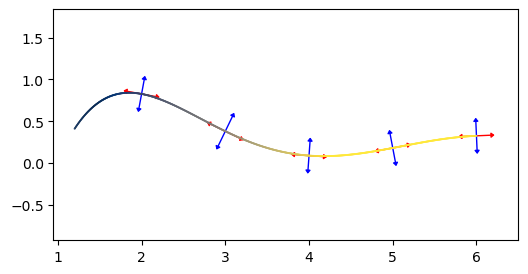

In [10]:
def manifold(x):
    #return -10.8 + 19.43855*x - 11.07751 * x**2 + 2.713738*x**3 - 0.2995921*x**4 + 0.01227564*x**5 + np.sin(x)
    return -5.175 + 9.032523*x - 4.855696*x**2 + 1.148834*x**3 - 0.1245484*x**4 + 0.005064103*x**5

def mani_grad(x):
    #return -10.8 + 19.43855*x - 11.07751 * x**2 + 2.713738*x**3 - 0.2995921*x**4 + 0.01227564*x**5 + np.sin(x)
    return 9.032523 - 2*4.855696*x + 3*1.148834*x**2 - 4*0.1245484*x**3 + 5*0.005064103*x**4

def arrow_at(ax, x, length=.5):

    anchor = np.array((x, manifold(x)))
    move = np.array((length, length * mani_grad(x)))
    
    # perpendicular arrow
    s = anchor - 0.5 * move
    e = s + move
    arrow = mpatches.FancyArrowPatch(s, e, mutation_scale=2, 
                                     arrowstyle='<|-|>,head_width=0.7,head_length=0.9', color='red')
    ax.add_patch(arrow)
    
    # rotation 
    rot_matrix = np.array(((0, 1), (-1, 0)))  
    move_rot = rot_matrix @ move
    
    # normal arrow
    s_rot = anchor - 0.5 * move_rot
    e_rot = s_rot + move_rot
    
    arrow = mpatches.FancyArrowPatch(s_rot, e_rot, mutation_scale=2, color='blue',
                                     arrowstyle='<|-|>,head_width=0.7,head_length=0.9')
    ax.add_patch(arrow)
    

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6, 3), squeeze=True, dpi=100)
ax.axis('equal')
#ax.patch.set_facecolor('black')

for a in range(2,7):
    arrow_at(ax, a)


x = np.linspace(1.2, 6, 1000)
#ax.plot(x, manifold(x), color='red', c=x)
vmax = np.max(x) * 0.7
vmin = np.min(x) * 1.2
ax.scatter(x, manifold(x), c=x, s=.1, cmap='cividis', vmax=vmax, vmin=vmin)


polygons1 = [Point(x, manifold(x)).buffer(10) for x in np.linspace(1.2, 6, 100)]
polygons1 = cascaded_union(polygons1)

for polygon1 in polygons1:
    polygon1 = ptc.Polygon(np.array(polygon1.exterior), facecolor="red", lw=0, alpha=alpha)
    ax.add_patch(polygon1)
    
#x = np.linspace(1.2, 6, 100)
#ax.scatter(x, manifold(x), c=x, s=100, linewidths=0, alpha=.1, cmap='cividis', vmax=vmax, vmin=vmin)
#ax.plot(x, manifold(x), color='red')

#arrow_at(ax, 2)

ax.set_yticks([])
ax.set_xticks([])

for spine in ax.spines.values():
    spine.set_edgecolor('black')

#plt.savefig('E:/normal_and_uniform.pdf', format='pdf', bbox_inches='tight')